In [1]:
pip install pandas_ta

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import yfinance as yf
import pandas as pd
import time
from datetime import datetime, timedelta
import pandas_ta as ta

# ------------------ DATE RANGE (LAST 2 YEARS) ------------------ #
end_date = datetime.today()
start_date = end_date - timedelta(days=1460)

# ------------------ 100 SMALL CAP NSE STOCKS ------------------ #

tickers = [
    # IT / Software / Tech
    "TANLA.NS","ZENSARTECH.NS","INTELLECT.NS","HAPPSTMNDS.NS","RATEGAIN.NS",
    "SUBEXLTD.NS","NEWGEN.NS","AFFLE.NS","KPITTECH.NS","LATENTVIEW.NS",
    "COFORGE.NS","SONATSOFTW.NS","MASTEK.NS","NIITLTD.NS","QUICKHEAL.NS",

    # Pharma / Healthcare
    "AARTIDRUGS.NS","CAPLIPOINT.NS","ERIS.NS","JBCHEPHARM.NS","GRANULES.NS",
    "SUVENPHAR.NS","NATCOPHARM.NS","IPCALAB.NS","GLAND.NS","AJANTPHARM.NS",
    "SANOFI.NS","PFIZER.NS","MARKSANS.NS","INDOCO.NS","NEULANDLAB.NS",

    # Chemicals / Specialty
    "AARTISURF.NS","NAVINFLUOR.NS","FINEORG.NS","ROSSARI.NS","CHEMPLASTS.NS",
    "DEEPAKNTR.NS","BALAMINES.NS","ALKYLAMINE.NS","VINATIORGA.NS","SRF.NS",
    "GHCL.NS","MEGH.NS","ANURAS.NS","PRIVISCL.NS","IOLCP.NS",

    # Auto & Auto Ancillaries
    "SONACOMS.NS","JBMA.NS","ENDURANCE.NS","SUPRAJIT.NS","MINDAIND.NS",
    "SANDHAR.NS","PRICOLLTD.NS","JTEKTINDIA.NS","ROLEXRINGS.NS","RACLGEAR.NS",
    "MOTHERSUMI.NS","TVSMOTOR.NS","ASHOKLEY.NS","AMARAJABAT.NS","GABRIEL.NS",

    # Financials / NBFC / Banks
    "IIFL.NS","AAVAS.NS","MASFIN.NS","CSBBANK.NS","DCBBANK.NS",
    "UJJIVANSFB.NS","SURYODAY.NS","EDELWEISS.NS","CAMS.NS","MCX.NS",
    "KARURVYSYA.NS","CITYUNION.NS","EQUITASBNK.NS","SBICARD.NS","CHOLAFIN.NS",

    # Consumer / FMCG / Retail
    "VMART.NS","JYOTHYLAB.NS","GOCOLORS.NS","TASTYBITE.NS","RADICO.NS",
    "VGUARD.NS","DOLLAR.NS","NILKAMAL.NS","TTKPRESTIG.NS","EVEREADY.NS",
    "RELAXO.NS","BAJAJCON.NS","EMAMILTD.NS","GILLETTE.NS","MARICO.NS",

    # Infrastructure / Capital Goods
    "KNRCON.NS","ENGINERSIN.NS","ISGEC.NS","RITES.NS","IRB.NS",
    "JINDALSAW.NS","PRAJIND.NS","KEI.NS","APLAPOLLO.NS","GRINFRA.NS",
    "NBCC.NS","HUDCO.NS","NCC.NS","L&TTS.NS","THERMAX.NS",

    # Power / Energy / Utilities
    "BORORENEW.NS","INOXWIND.NS","SJVN.NS","NHPC.NS","RECLTD.NS",
    "IREDA.NS","CESC.NS","TATAPOWER.NS","JSWENERGY.NS","ADANIPOWER.NS",
    "TORNTPOWER.NS","POWERINDIA.NS","GUJGASLTD.NS","ONGC.NS","OIL.NS",

    # Telecom / Electronics / EMS
    "HFCL.NS","TEJASNET.NS","STEL.NS","SYRMA.NS","DIXON.NS",
    "AMBER.NS","CENTUM.NS","AVALON.NS","PGEL.NS","DATAEDGE.NS",
    "ROUTE.NS","EASEMYTRIP.NS","JUSTDIAL.NS","NAUKRI.NS","MTARTECH.NS",

    # Textiles / Apparel
    "WELSPUNIND.NS","VARDHACRLC.NS","TRIDENT.NS","KITEX.NS","KPRMILL.NS",
    "DONEAR.NS","RAYMOND.NS","SIYSIL.NS","SPANDANA.NS","GOKEX.NS",

    # Logistics / Services / Misc
    "BLUEDART.NS","TCI.NS","SIS.NS","QUESS.NS","VAIBHAVGBL.NS",
    "LEMONTREE.NS","INDIAMART.NS","MEDPLUS.NS","GLS.NS","APLLTD.NS",

    # Metals / Industrial
    "JSL.NS","HINDCOPPER.NS","NATIONALUM.NS","RATNAMANI.NS","KIRLOSBROS.NS",
    "MAHSEALS.NS","MSPL.NS","SAKUMA.NS","VSTTILLERS.NS","UGARSUGAR.NS",

    # Media / Realty (small-cap biased)
    "INOXLEISUR.NS","TIPSINDLTD.NS","TV18BRDCST.NS","ZEEL.NS","SUNTV.NS",
    "TARC.NS","SOBHA.NS","BRIGADE.NS","PRESTIGE.NS","OBEROIRLTY.NS"
]

# ------------------ CHUNK SETTINGS ------------------ #
chunk_size = 10
pause_time = 30  # seconds

all_data = []

# ------------------ DOWNLOAD IN CHUNKS ------------------ #
for i in range(0, len(tickers), chunk_size):

    chunk = tickers[i:i + chunk_size]
    print(f"Downloading chunk {i//chunk_size + 1} → {chunk}")

    data = yf.download(
        chunk,
        start=start_date,
        end=end_date,
        interval="1d",
        group_by="ticker",
        threads=True,
        progress=False
    )

    chunk_df = (
        data.stack(level=0)
        .rename_axis(["Date", "Ticker"])
        .reset_index()
    )

    all_data.append(chunk_df)

    # ⏸ Pause after every chunk except the last
    if i + chunk_size < len(tickers):
        print(f"Sleeping for {pause_time} seconds...\n")
        time.sleep(pause_time)

# ------------------ COMBINE & SAVE ------------------ #
final_df = pd.concat(all_data, ignore_index=True)
final_df = final_df[["Date","Ticker","Open","High","Low","Close","Volume"]]
final_df = final_df.sort_values(["Ticker","Date"]).reset_index(drop=True)

print("Final Shape:", final_df.shape)
print(final_df.head())

# Save OHLCV data
final_df.to_csv("nse_smallcap_last_2y_daily_ohlcv.csv", index=False)

# ===================== DATA CLEANING =====================
df = final_df.copy()

# Check for missing values
rows_with_missing = df[df.isnull().any(axis=1)]
print(f"\nRows with missing values: {len(rows_with_missing)}")
print(rows_with_missing.head(10))

# Remove rows with missing values
df = df.dropna()
print("\nNull values after cleaning:")
print(df.isnull().sum())
print(f"Final cleaned shape: {df.shape}")

# ===================== FEATURE ENGINEERING =====================
df = df.sort_values(["Ticker", "Date"])

def create_ga_daily_features_group(df_group):
    group = df_group.copy()

    # ================= TREND ================= #
    group["EMA50"] = ta.ema(group["Close"], length=50)
    group["EMA200"] = ta.ema(group["Close"], length=200)
    group["EMA_RATIO"] = group["EMA50"] / group["EMA200"]

    macd = ta.macd(group["Close"])
    group["MACD"] = macd["MACD_12_26_9"]
    group["MACD_SIGNAL"] = macd["MACDs_12_26_9"]
    group["MACD_HIST"] = macd["MACDh_12_26_9"]

    # ================= MEAN-REVERSION ================= #
    group["RSI14"] = ta.rsi(group["Close"], length=14)

    bb = ta.bbands(group["Close"], length=20)
    bb_cols = bb.columns.tolist()
    bb_mid = [col for col in bb_cols if "BBM" in col][0]
    bb_upper = [col for col in bb_cols if "BBU" in col][0]
    bb_lower = [col for col in bb_cols if "BBL" in col][0]

    group["BB_MID"] = bb[bb_mid]
    group["BB_WIDTH"] = bb[bb_upper] - bb[bb_lower]

    # ================= VOLATILITY ================= #
    group["ATR14"] = ta.atr(group["High"], group["Low"], group["Close"], length=14)
    group["VOLATILITY"] = group["Close"].rolling(14).std()

    # ================= MOMENTUM / VOLUME ================= #
    group["OBV"] = ta.obv(group["Close"], group["Volume"])
    stoch = ta.stoch(group["High"], group["Low"], group["Close"], k=14, d=3)
    group["STOCH_K"] = stoch["STOCHk_14_3_3"]
    group["STOCH_D"] = stoch["STOCHd_14_3_3"]

    # ================= DAILY TARGET ================= #
    group["future_close_5d"] = group["Close"].shift(-5)
    group["ret_pct_5d"] = (group["future_close_5d"] - group["Close"]) / group["Close"] * 100
    group["y_5d_class"] = group["daily_ret_pct"].apply(lambda x: 1 if x > 2.0 else 0)

    # Drop helper columns
    group = group.drop(columns=["future_close_5d", "ret_pct_5d"])

    return group

# Apply to each ticker
df = df.groupby("Ticker", group_keys=True).apply(create_ga_daily_features_group)

# Drop NaNs
df = df.dropna().reset_index(drop=True)

print("\n========== FINAL FEATURE DATASET ==========")
print(df.head())
print(f"\nFinal shape with features: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Save feature engineered data
df.to_csv("nse_smallcap_features_engineered.csv", index=False)
print("\nData saved to 'nse_smallcap_features_engineered.csv'")

Sleeping for 30 seconds...

Sleeping for 30 seconds...



$SUVENPHAR.NS: possibly delisted; no timezone found

1 Failed download:
['SUVENPHAR.NS']: possibly delisted; no timezone found


Sleeping for 30 seconds...

Sleeping for 30 seconds...



$MINDAIND.NS: possibly delisted; no timezone found
$MEGH.NS: possibly delisted; no timezone found

2 Failed downloads:
['MINDAIND.NS', 'MEGH.NS']: possibly delisted; no timezone found


Sleeping for 30 seconds...



...

$GLS.NS: possibly delisted; no timezone found

1 Failed download:
['GLS.NS']: possibly delisted; no timezone found


Sleeping for 30 seconds...



$TIPSINDLTD.NS: possibly delisted; no timezone found


$TV18BRDCST.NS: possibly delisted; no timezone found
$INOXLEISUR.NS: possibly delisted; no timezone found
$MAHSEALS.NS: possibly delisted; no timezone found

4 Failed downloads:
['TIPSINDLTD.NS', 'TV18BRDCST.NS', 'INOXLEISUR.NS', 'MAHSEALS.NS']: possibly delisted; no timezone found


Sleeping for 30 seconds...

Final Shape: (172725, 7)
Price       Date         Ticker        Open        High         Low  \
0     2022-04-01  AARTIDRUGS.NS  424.792128  459.170641  424.792128   
1     2022-04-04  AARTIDRUGS.NS  459.368197  472.803488  456.552708   
2     2022-04-05  AARTIDRUGS.NS  472.111934  507.972306  467.271286   
3     2022-04-06  AARTIDRUGS.NS  500.661919  513.702061  498.883732   
4     2022-04-07  AARTIDRUGS.NS  510.145610  524.963937  507.922861   

Price       Close    Volume  
0      453.638489  350018.0  
1      464.702789  275941.0  
2      498.340393  828071.0  
3      506.095306  502184.0  
4      513.504395  449211.0  

Rows with missing values: 15264
Price       Date         Ticker  Open  High  Low  Close  Volume
1924  2026-01-15   AARTISURF.NS   NaN   NaN  NaN    NaN     NaN
5872  2026-01-15  AJANTPHARM.NS   NaN   NaN  NaN    NaN     NaN
6909  2022-04-01  AMARAJABAT.NS   NaN   NaN  NaN    NaN     NaN
6910  2022-04-04  AMARAJABAT.NS   NaN   NaN  NaN   

In [13]:
# ===================== TRAIN-TEST SPLIT =====================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop(columns=["y_5d_class", "Date"], errors="ignore")
y = df["y_5d_class"]

print(f"Feature columns: {X.columns.tolist()}")
print(f"Target distribution:\n{y.value_counts()}")

# 80-20 split
split_date = df["Date"].quantile(0.85)

X_train = X[df["Date"] <= split_date]
X_test  = X[df["Date"] >  split_date]

y_train = y[df["Date"] <= split_date]
y_test  = y[df["Date"] >  split_date]

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train shape: {X_train_scaled.shape}")
print(f"Test shape: {X_test_scaled.shape}")

Feature columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'EMA50', 'EMA200', 'EMA_RATIO', 'MACD', 'MACD_SIGNAL', 'MACD_HIST', 'RSI14', 'BB_MID', 'BB_WIDTH', 'ATR14', 'VOLATILITY', 'OBV', 'STOCH_K', 'STOCH_D']
Target distribution:
y_5d_class
0    76120
1    49302
Name: count, dtype: int64
Train shape: (106610, 19)
Test shape: (18812, 19)


c:\Users\steve\OneDrive\Desktop\Full stack data science\XGBoost Project\stock_prediction\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:48:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



MODEL PERFORMANCE - SMALL CAP NSE STOCKS
Accuracy: 0.5478
AUC-ROC: 0.5145

Classification Report:
              precision    recall  f1-score   support

        Down       0.66      0.64      0.65     12252
          Up       0.36      0.38      0.37      6560

    accuracy                           0.55     18812
   macro avg       0.51      0.51      0.51     18812
weighted avg       0.55      0.55      0.55     18812


Confusion Matrix:
[[7823 4429]
 [4078 2482]]


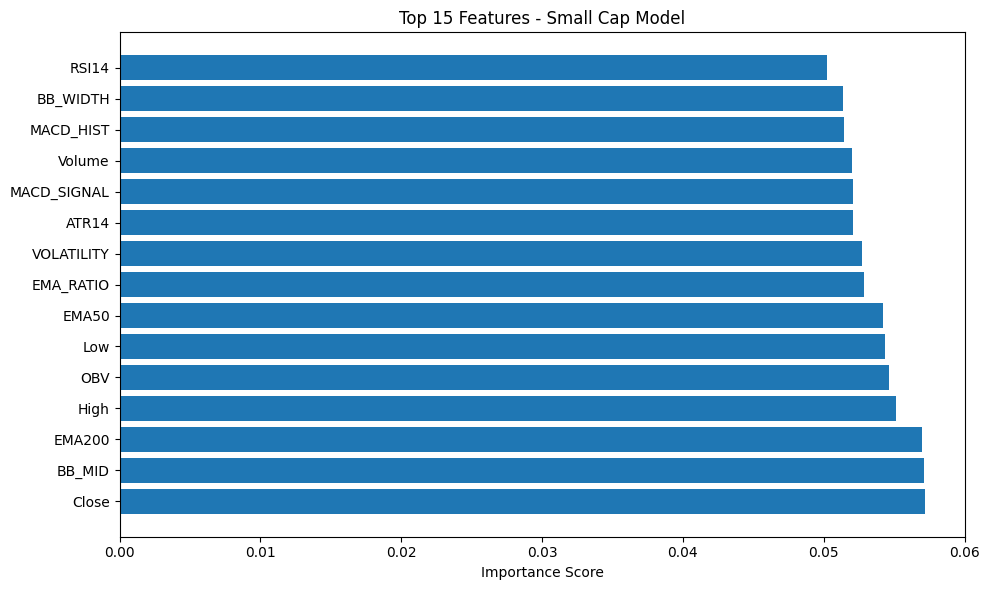


Top 10 Features:
       Feature  Importance
3        Close    0.057197
12      BB_MID    0.057145
6       EMA200    0.056960
1         High    0.055100
16         OBV    0.054620
2          Low    0.054372
5        EMA50    0.054229
7    EMA_RATIO    0.052862
15  VOLATILITY    0.052701
14       ATR14    0.052106


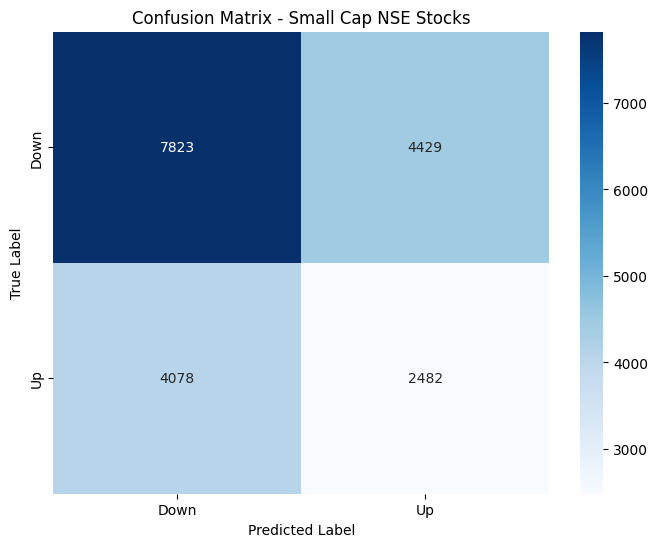

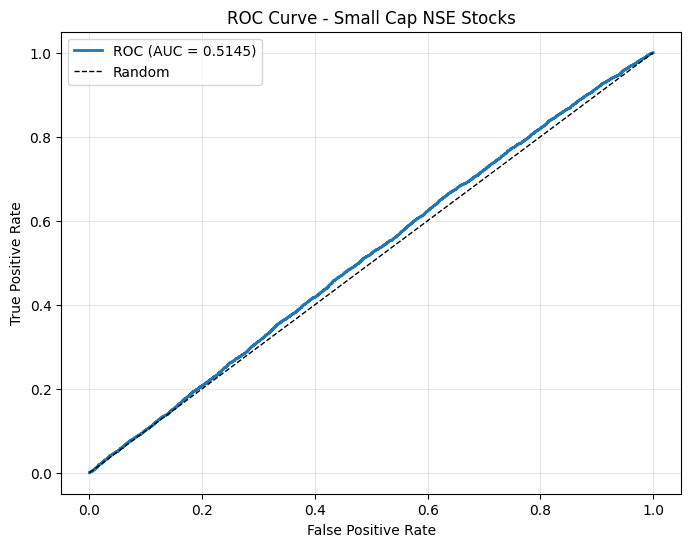

In [14]:
# ===================== MODEL TRAINING (XGBoost) =====================
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute dynamic scale_pos_weight
num_class0 = np.sum(y_train == 0)
num_class1 = np.sum(y_train == 1)
scale_pos_weight = num_class0 / num_class1  # dynamic

# Train XGBoost with dynamic weighting
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

model.fit(X_train_scaled, y_train)

# ===================== PREDICTIONS & EVALUATION =====================
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "="*50)
print("MODEL PERFORMANCE - SMALL CAP NSE STOCKS")
print("="*50)
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC-ROC: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Down', 'Up']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:\n{cm}")

# ===================== VISUALIZATION =====================
# 1. Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'].head(15), feature_importance['Importance'].head(15))
plt.xlabel('Importance Score')
plt.title('Top 15 Features - Small Cap Model')
plt.tight_layout()
plt.savefig('smallcap_feature_importance.png', dpi=300)
plt.show()

print("\nTop 10 Features:")
print(feature_importance.head(10))

# 2. Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title('Confusion Matrix - Small Cap NSE Stocks')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('smallcap_confusion_matrix.png', dpi=300)
plt.show()

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC (AUC = {auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Small Cap NSE Stocks')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('smallcap_roc_curve.png', dpi=300)
plt.show()


In [5]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
# ===================== SAVE MODEL & SCALER =====================
import joblib

artifact = {
    "model": model,
    "scaler": scaler
}

joblib.dump(artifact, "smallcap_xgboost_artifact.joblib")

# Save feature importance separately
feature_importance.to_csv("smallcap_feature_importance.csv", index=False)

print("\n✅ Model & scaler saved together as 'smallcap_xgboost_artifact.joblib'")
print("✅ Feature importance saved as 'smallcap_feature_importance.csv'")


✅ Model & scaler saved together as 'smallcap_xgboost_artifact.joblib'
✅ Feature importance saved as 'smallcap_feature_importance.csv'


In [17]:
# ===================== FUNCTION TO CREATE FEATURES =====================
def create_features_for_ticker(ticker_symbol, days=200):
    """
    Download data for a ticker and create all required features
    """

    try:
        # Download historical data
        end_date = datetime.today()
        start_date = end_date - timedelta(days=days)

        print(f"📥 Downloading data for {ticker_symbol}...")
        data = yf.download(
            ticker_symbol,
            start=start_date,
            end=end_date,
            interval="1d",
            progress=False
        )

        if data.empty:
            print(f"❌ No data found for {ticker_symbol}")
            return None

        # Reset index
        data = data.reset_index()

        # Handle case where columns might be MultiIndex
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.droplevel(1)

        print(f"   Downloaded {len(data)} rows of data")

        # ================= CREATE FEATURES ================= #

        # TREND Features
        data['EMA50'] = ta.ema(data['Close'], length=50)
        data['EMA200'] = ta.ema(data['Close'], length=200)

        # Handle division by zero
        data['EMA_RATIO'] = np.where(
            data['EMA200'] != 0,
            data['EMA50'] / data['EMA200'],
            1.0
        )

        # MACD - with error handling
        macd_result = ta.macd(data['Close'], fast=12, slow=26, signal=9)
        if macd_result is not None and not macd_result.empty:
            macd_cols = macd_result.columns.tolist()
            macd_col = [col for col in macd_cols if "MACD_" in col and "s" not in col][0] if macd_cols else None
            signal_col = [col for col in macd_cols if "MACDs_" in col][0] if macd_cols else None
            hist_col = [col for col in macd_cols if "MACDh_" in col][0] if macd_cols else None

            if macd_col:
                data['MACD'] = macd_result[macd_col]
            else:
                data['MACD'] = 0

            if signal_col:
                data['MACD_SIGNAL'] = macd_result[signal_col]
            else:
                data['MACD_SIGNAL'] = 0

            if hist_col:
                data['MACD_HIST'] = macd_result[hist_col]
            else:
                data['MACD_HIST'] = 0
        else:
            data['MACD'] = 0
            data['MACD_SIGNAL'] = 0
            data['MACD_HIST'] = 0

        # RSI
        data['RSI14'] = ta.rsi(data['Close'], length=14)

        # Bollinger Bands
        bb_result = ta.bbands(data['Close'], length=20)
        if bb_result is not None and not bb_result.empty:
            bb_cols = bb_result.columns.tolist()
            bb_mid = [col for col in bb_cols if "BBM" in col]
            bb_upper = [col for col in bb_cols if "BBU" in col]
            bb_lower = [col for col in bb_cols if "BBL" in col]

            if bb_mid:
                data['BB_MID'] = bb_result[bb_mid[0]]
            else:
                data['BB_MID'] = data['Close']

            if bb_upper and bb_lower:
                data['BB_WIDTH'] = bb_result[bb_upper[0]] - bb_result[bb_lower[0]]
            else:
                data['BB_WIDTH'] = 0
        else:
            data['BB_MID'] = data['Close']
            data['BB_WIDTH'] = 0

        # ATR
        atr_result = ta.atr(data['High'], data['Low'], data['Close'], length=14)
        if atr_result is not None:
            data['ATR14'] = atr_result
        else:
            data['ATR14'] = data['High'] - data['Low']

        # Volatility
        data['VOLATILITY'] = data['Close'].rolling(14).std()

        # OBV
        obv_result = ta.obv(data['Close'], data['Volume'])
        if obv_result is not None:
            data['OBV'] = obv_result
        else:
            data['OBV'] = 0

        # Stochastic - with error handling
        stoch_result = ta.stoch(data['High'], data['Low'], data['Close'], k=14, d=3)
        if stoch_result is not None and not stoch_result.empty:
            stoch_cols = stoch_result.columns.tolist()
            stoch_k = [col for col in stoch_cols if "STOCHk_" in col]
            stoch_d = [col for col in stoch_cols if "STOCHd_" in col]

            if stoch_k:
                data['STOCH_K'] = stoch_result[stoch_k[0]]
            else:
                data['STOCH_K'] = 50

            if stoch_d:
                data['STOCH_D'] = stoch_result[stoch_d[0]]
            else:
                data['STOCH_D'] = 50
        else:
            data['STOCH_K'] = 50
            data['STOCH_D'] = 50

        # Fill remaining NaN values
        data = data.ffill().bfill().fillna(0)

        # Remove rows where all features are 0 or NaN
        data = data.dropna(subset=['Close', 'Volume'])

        print(f"✅ Features created! Total rows: {len(data)}")

        return data

    except Exception as e:
        print(f"❌ Error processing {ticker_symbol}: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

# ===================== FUNCTION TO MAKE PREDICTIONS =====================
def predict_next_day(ticker_symbol, days=200):
    """
    Predict next day's price movement for a custom small-cap stock
    """

    # Get data with features
    data = create_features_for_ticker(ticker_symbol, days=days)

    if data is None or len(data) < 50:
        print(f"❌ Insufficient data for {ticker_symbol}")
        return None

    # Feature columns (must match training)
    feature_columns = [
        'Open', 'High', 'Low', 'Close', 'Volume',
        'EMA50', 'EMA200', 'EMA_RATIO', 'MACD', 'MACD_SIGNAL', 'MACD_HIST',
        'RSI14', 'BB_MID', 'BB_WIDTH', 'ATR14', 'VOLATILITY',
        'OBV', 'STOCH_K', 'STOCH_D'
    ]

    # Verify all features exist
    missing_cols = [col for col in feature_columns if col not in data.columns]
    if missing_cols:
        print(f"❌ Missing columns: {missing_cols}")
        return None

    # Get latest row (today's data)
    latest_data = data.iloc[-1:][feature_columns].copy()

    # Check for NaN values
    if latest_data.isnull().any().any():
        print(f"⚠️  Filling NaN values in {ticker_symbol}")
        latest_data = latest_data.fillna(latest_data.mean())

    try:
        # Scale features
        latest_scaled = scaler.transform(latest_data)

        # Make prediction
        prediction_prob = model.predict_proba(latest_scaled)[0]
        prediction_class = model.predict(latest_scaled)[0]

        # Extract results
        current_price = data.iloc[-1]['Close']
        prediction_date = data.iloc[-1]['Date']

        # Interpret prediction
        if prediction_class == 1:
            signal = "🟢 UP"
            confidence = prediction_prob[1]
        else:
            signal = "🔴 DOWN"
            confidence = prediction_prob[0]

        return {
            'Ticker': ticker_symbol,
            'Date': prediction_date,
            'Current_Price': current_price,
            'Prediction': signal,
            'Confidence': confidence,
            'UP_Probability': prediction_prob[1],
            'DOWN_Probability': prediction_prob[0]
        }

    except Exception as e:
        print(f"❌ Prediction error for {ticker_symbol}: {str(e)}")
        return None

# ===================== PREDICT SINGLE STOCK =====================

print("\n" + "="*60)
print("SINGLE STOCK PREDICTION")
print("="*60)

result = predict_next_day('SBICARD.NS')

if result:
    print(f"\n✅ PREDICTION SUCCESSFUL!")
    print(f"Ticker: {result['Ticker']}")
    print(f"Date: {result['Date']}")
    print(f"Current Price: ₹{result['Current_Price']:.2f}")
    print(f"Prediction: {result['Prediction']}")
    print(f"Confidence: {result['Confidence']:.4f} ({result['Confidence']*100:.2f}%)")
    print(f"UP Probability: {result['UP_Probability']:.4f}")
    print(f"DOWN Probability: {result['DOWN_Probability']:.4f}")
else:
    print("❌ Prediction failed. Check your model files and internet connection.")



SINGLE STOCK PREDICTION
📥 Downloading data for SBICARD.NS...
   Downloaded 135 rows of data
✅ Features created! Total rows: 135

✅ PREDICTION SUCCESSFUL!
Ticker: SBICARD.NS
Date: 2026-03-30 00:00:00
Current Price: ₹635.45
Prediction: 🟢 UP
Confidence: 0.6711 (67.11%)
UP Probability: 0.6711
DOWN Probability: 0.3289


In [20]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib

import joblib

# Load the file
model_data = joblib.load("smallcap_xgboost_artifact.joblib")


xgb_model = model_data['model']
scaler    = model_data['scaler']

# ===================== 2. Fetch Midcap Data ===================== #
ticker = "IIFL.NS"  # replace with your midcap ticker
start_date = "2020-01-01"
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")

df_raw = yf.Ticker(ticker).history(start=start_date, end=end_date)
if df_raw.empty:
    print("No data fetched. Check ticker or date range.")
    exit()

df_raw = df_raw.reset_index()

# ===================== 3. Feature Engineering ===================== #
def create_features(df):
    df = df.copy()
    
    df["EMA50"] = ta.ema(df["Close"], length=50)
    df["EMA200"] = ta.ema(df["Close"], length=200)
    df["EMA_RATIO"] = df["EMA50"] / df["EMA200"]

    macd = ta.macd(df["Close"])
    df["MACD"] = macd["MACD_12_26_9"]
    df["MACD_SIGNAL"] = macd["MACDs_12_26_9"]
    df["MACD_HIST"] = macd["MACDh_12_26_9"]

    df["RSI14"] = ta.rsi(df["Close"], length=14)

    # Bollinger Bands dynamically
    bb = ta.bbands(df["Close"], length=20)
    bb_cols = bb.columns.tolist()
    bb_mid   = [c for c in bb_cols if "BBM" in c][0]
    bb_upper = [c for c in bb_cols if "BBU" in c][0]
    bb_lower = [c for c in bb_cols if "BBL" in c][0]
    df["BB_MID"] = bb[bb_mid]
    df["BB_WIDTH"] = bb[bb_upper] - bb[bb_lower]

    df["ATR14"] = ta.atr(df["High"], df["Low"], df["Close"], length=14)
    df["VOLATILITY"] = df["Close"].rolling(14).std()
    df["OBV"] = ta.obv(df["Close"], df["Volume"])

    stoch = ta.stoch(df["High"], df["Low"], df["Close"], k=14, d=3)
    df["STOCH_K"] = stoch["STOCHk_14_3_3"]
    df["STOCH_D"] = stoch["STOCHd_14_3_3"]

    df = df.dropna().reset_index(drop=True)
    return df

df_features = create_features(df_raw)

# ===================== 4. Regime ===================== #
df_features["Return20"] = df_features["Close"].pct_change()
df_features["Regime"] = df_features["Return20"].rolling(20).mean().apply(
    lambda x: "Bullish" if x > 0 else "Bearish"
)

# ===================== 5. Hybrid Signal Function for Midcap ===================== #
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'EMA50', 'EMA200',
                'EMA_RATIO', 'MACD', 'MACD_SIGNAL', 'MACD_HIST', 'RSI14', 
                'BB_MID', 'BB_WIDTH', 'ATR14', 'VOLATILITY', 'OBV', 
                'STOCH_K', 'STOCH_D']

def hybrid_signal_midcap(Xt_row, Pt, Cash, model, scaler, regime):
    # Predict ML signal
    X_scaled = scaler.transform(Xt_row)
    y_hat = model.predict(X_scaled)[0]  # 0=Sell, 1=Buy

    # Extract indicators
    EMA50  = Xt_row["EMA50"].values[0]
    EMA200 = Xt_row["EMA200"].values[0]
    MACD   = Xt_row["MACD"].values[0]
    MACD_SIGNAL = Xt_row["MACD_SIGNAL"].values[0]
    RSI14  = Xt_row["RSI14"].values[0]
    ATR    = Xt_row["ATR14"].values[0]
    VOL    = Xt_row["VOLATILITY"].values[0]
    STOCH_K = Xt_row["STOCH_K"].values[0]
    STOCH_D = Xt_row["STOCH_D"].values[0]
    BB_WIDTH = Xt_row["BB_WIDTH"].values[0]

    score_buy = 0

    # Short-term momentum stronger in small caps
    if Pt > EMA50 and MACD > MACD_SIGNAL:
        score_buy += 1.0
    # RSI slightly lower threshold to catch early moves
    if RSI14 < 45 and y_hat == 1:
        score_buy += 1.2
    # Small-cap bullish trend may be less consistent
    if Pt > EMA200 and regime == "Bullish":
        score_buy += 0.8
    # Stochastic oversold trigger
    if STOCH_K < 25 and STOCH_K < STOCH_D:
        score_buy += 1.0

    if score_buy >= 2.0:  # Lower threshold than large-cap
        risk_trade = 0.015 * Cash  # slightly higher risk for small caps
        shares_at_risk = risk_trade / ATR
        shares_cap = 0.1 * Cash / Pt
        shares = min(shares_at_risk, shares_cap)
        return "Buy", int(shares)

    # ========================= Sell Logic (small-cap) ================= #
    elif y_hat == 0:
        score_sell = 0

        if RSI14 > 60:  # overbought
            score_sell += 1.0
        if Pt < EMA200:  # weakening long-term trend
            score_sell += 1.2
        if Pt < EMA50:  # weakening short-term trend
            score_sell += 0.8
        if MACD < MACD_SIGNAL:  # negative momentum
            score_sell += 0.8
        if STOCH_K > 75 and STOCH_K > STOCH_D:  # overbought stochastic
            score_sell += 0.6
        if VOL > 0.05 * Pt:  # small caps are more volatile
            score_sell += 0.5

        if score_sell >= 1.5:  # same lenient threshold
            return "Sell", "Full"
        else:
            return "Hold", 0

    else:
        return "Hold", 0


# ===================== 6. Predict Latest Row ===================== #
Xt = df_features.iloc[[-1]][feature_cols]
Pt = df_features.iloc[-1]["Close"]
current_regime = df_features.iloc[-1]["Regime"]

signal, position = hybrid_signal_midcap(
    Xt, Pt, Cash=100000, model=xgb_model, scaler=scaler, regime=current_regime
)

# ===================== 7. Output ===================== #
print(f"Ticker: {ticker}")
print(f"Date: {df_features.iloc[-1]['Date']}")
print(f"Signal: {signal}")
print(f"Shares: {position}")

Ticker: IIFL.NS
Date: 2026-03-30 00:00:00+05:30
Signal: Buy
Shares: 23
